# DataDriven_Soccer_Scouting

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
#from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import time
import subprocess
import sys
from cluster_functions import plot_cluster_positions, plot_cluster_league

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "nbformat"])

import warnings
warnings.filterwarnings("ignore")

start_time = time.time()

ModuleNotFoundError: No module named 'tensorflow.python'

## Introduction and EDA

In [ ]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

# Keep "Position" column instead of "pos"
df.drop(columns=['pos'], inplace=True)
df = df.rename(columns={'Position': 'pos'})

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,age,born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,26,1997,17,13,1198,...,28,214,55,813,367,813,NaN,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,25,20,1729,...,162,57,6,978,216,979,178.0,65.0,Left,RW
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,28,1995,38,38,3420,...,0,1388,880,1480,92,1480,183.0,75.0,Right,GK
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,35,33,2825,...,81,325,82,1948,909,1948,185.0,80.0,Right,CDM
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,26,1997,28,28,2363,...,40,672,189,1873,985,1873,NaN,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [ ]:
# Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3392 
- columns: 117


In [ ]:
# Select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,Preferred foot,pos
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,Left,RW
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,Right,CDM
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,Right,LW
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,Left,CB
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,Right,RB


In [ ]:
# Rename 'Preferred foot' to 'preferred_foot' for consistency
df.rename(columns={'Preferred foot': 'preferred_foot'}, inplace=True)

# Convert preferred_foot to binary (1 for 'Right', 0 for 'Left')
df['preferred_foot_binary'] = df['preferred_foot'].map({'Right': 1, 'Left': 0})

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age', 'preferred_foot']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Matrix 'X' shape: 3392 players x 109 statistics


## Similarity Search

### PCA - BOSCA

In [ ]:
# ----------------------------------------------
# NON RIMUOVERE QUESTA CELLA
# ----------------------------------------------
df_info_reset = df_info.reset_index(drop=True)
df_info_reset

,league,season,team,player,nation,age,born,preferred_foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,Left,RW
1,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,Right,CDM
2,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,23,2001,Right,LW
3,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,24,2000,Left,CB
4,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,23,2001,Right,RB
...,...,...,...,...,...,...,...,...,...
3387,ITA-Serie A,2022 - 2023,Udinese,Lazar Samardzic,SRB,20,2002,Left,CM
3388,ITA-Serie A,2022 - 2023,Udinese,Nehuén Pérez,ARG,22,2000,Right,CB
3389,ITA-Serie A,2022 - 2023,Udinese,Roberto Pereyra,ARG,31,1991,Right,CM
3390,ITA-Serie A,2022 - 2023,Udinese,Rodrigo Becão,BRA,26,1996,Right,CB


Total features: 109
Explained variance by first 10 components: [0.31189748 0.55161944 0.62883637 0.67460579 0.70771116 0.73855402
 0.76469147 0.78850566 0.80647616 0.82225722]
Variance explained by first 20 components: 0.9176
Components needed for 95% variance: 27
Components needed for 90% variance: 18


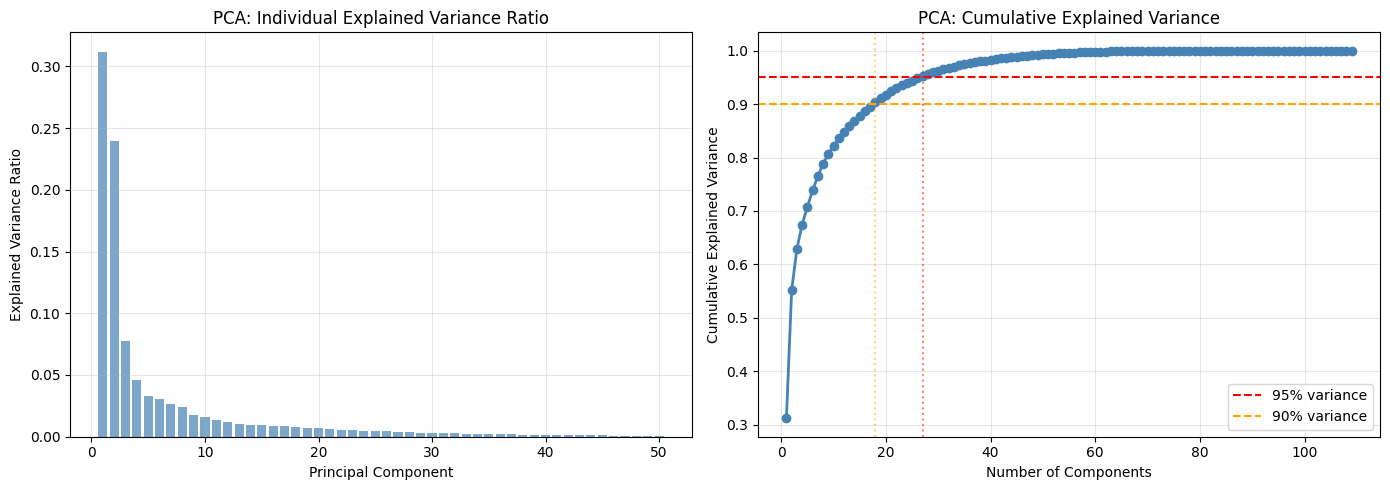

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Fitting PCA with all components to analyze explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Get explained variance ratio
explained_variance = pca_full.explained_variance_ratio_ #e.g. PC1 -> 40, PC2 -> 20, PC3 -> 10, ...
cumulative_variance = np.cumsum(explained_variance) #e.g. PC1 -> 40, PC2 -> 60, PC3 -> 70, ...

print(f"Total features: {X_scaled.shape[1]}")
print(f"Explained variance by first 10 components: {cumulative_variance[:10]}")
print(f"Variance explained by first 20 components: {cumulative_variance[19] if len(cumulative_variance) > 19 else cumulative_variance[-1]:.4f}")

# Find optimal number of components (95% variance)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

# Find optimal number of components (90% variance)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual explained variance
axes[0].bar(range(1, min(51, len(explained_variance) + 1)), explained_variance[:50], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA: Individual Explained Variance Ratio')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].axvline(x=n_components_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_90, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA: Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


First conclusion: Data is highly reducible: from 109 variables you can reduce to about 20–30 without losing much information.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=18)  # oppure 27
X_pca = pca.fit_transform(X_scaled)

In [ ]:
#LogisticRegression with PCA 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = df_info_reset['pos']  # Target: position

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7260677466863034


In [ ]:
#LogisticRegression without PCA
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy (no PCA):", accuracy_score(y_test, y_pred))

Accuracy (no PCA): 0.7187039764359352


Conclusion: The PCA model achieved an accuracy of 0.726 compared to 0.720 without PCA, while reducing the number of features from 109 to 18. This shows that dimensionality reduction can simplify the dataset without losing predictive performance.

### Deep Autoencoder - MURA

#### Mix ReLU

In [ ]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Mix Tanh

In [ ]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Relu

In [ ]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Mode

#### Tanh - to train

In [ ]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (tanh compression)\nencoded = layers.Dense(64, activation=\'tanh\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'tanh\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Mode

#### ReLU with dropout

In [ ]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=500, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(128, activation=\'relu\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(64, activation=\'relu\')(encoded)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\ndecoded = layers.Dense(128, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = la

#### Tanh with dropout - to train

In [ ]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=400, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh_dropout.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (tanh compression)\nencoded = layers.Dense(128, activation=\'tanh\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(64, activation=\'tanh\')(encoded)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'tanh\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\ndecoded = layers.Dense(128, activation=\'tanh\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = la

#### ReLU + Tanh bottleneck with dropout - to train

In [ ]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space, bounded by tanh)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=400, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_relu_tanh_btn.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_tanh_btn = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_tanh_btn = pd.concat([df_info_reset, df_ae_relu_tanh_btn], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space, bounded by tanh)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================

#### Testing Autoencoder

##### Similarity Functions

In [ ]:
def find_similar_ae(player_name, player_season, latent_df, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (latent_df['player'].str.lower() == player_name.lower())
        & (latent_df['season'] == player_season)
    )
    player_idx = latent_df[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    season = latent_df.loc[idx, 'season']
    role = latent_df.loc[idx, 'pos']

    print(f"\n[AUTOENCODER] Searching similar players for: {real_player} ({real_team} - {season})")

    # Extract target player's 10 latent values
    player_vector = latent_df.loc[idx, ae_columns].values.reshape(1, -1)
    # Extract all players' latent values
    all_vectors = latent_df[ae_columns].values

    # Compute cosine similarity
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Assign scores
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity

    # Exclude target player from results
    latent_df_temp = latent_df_temp.drop(index=idx)

    # Optional age filter
    if max_age is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['age'] <= max_age]

    # Optional season filter
    if season_filter is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['season'] == season_filter]

    # Optional position filter
    if same_position:
        latent_df_temp = latent_df_temp[latent_df_temp['pos'] == role]

    # Optional league filter
    if same_league:
        latent_df_temp = latent_df_temp[latent_df_temp['league'] == latent_df.loc[idx, 'league']]

    # Optional preferred-foot filter
    if same_preferred_foot:
        latent_df_temp = latent_df_temp[latent_df_temp['preferred_foot'] == latent_df.loc[idx, 'preferred_foot']]

    latent_df_temp = latent_df_temp[latent_df_temp['player'] != player_name]

    # Sort from most similar to least similar
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()

    # Format score as a readable percentage
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    output_columns = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return similar_players[output_columns]

In [ ]:
'''def find_similar_ensemble(
    player_name,
    player_season,
    latent_df_a=df_latent_ae_relu_tanh_btn,
    latent_df_b=df_latent_ae_tanh_dropout,
    latent_df_c=df_latent_ae_tanh,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (latent_df_a['player'].str.lower() == player_name.lower())
        & (latent_df_a['season'] == player_season)
    )
    player_idx = latent_df_a[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df_a.loc[idx, 'player']
    real_team = latent_df_a.loc[idx, 'team']
    season = latent_df_a.loc[idx, 'season']
    role = latent_df_a.loc[idx, 'pos']
    league = latent_df_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Searching similar players for: {real_player} ({real_team} - {season})")

    # Average cosine similarity from the three latent spaces
    vector_a = latent_df_a.loc[idx, ae_columns].values.reshape(1, -1)
    vector_b = latent_df_b.loc[idx, ae_columns].values.reshape(1, -1)
    vector_c = latent_df_c.loc[idx, ae_columns].values.reshape(1, -1)
    sim_a = cosine_similarity(vector_a, latent_df_a[ae_columns].values)[0]
    sim_b = cosine_similarity(vector_b, latent_df_b[ae_columns].values)[0]
    sim_c = cosine_similarity(vector_c, latent_df_c[ae_columns].values)[0]
    sim_ensemble = (sim_a + sim_b + sim_c) / 3

    df_temp = latent_df_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == role]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != player_name]

    similar_players = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return similar_players[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]'''

'def find_similar_ensemble(\n    player_name,\n    player_season,\n    latent_df_a=df_latent_ae_relu_tanh_btn,\n    latent_df_b=df_latent_ae_tanh_dropout,\n    latent_df_c=df_latent_ae_tanh,\n    top_n=5,\n    max_age=None,\n    season_filter=None,\n    same_position=False,\n    same_league=False\n):\n    # Target player\n    mask_target = (\n        (latent_df_a[\'player\'].str.lower() == player_name.lower())\n        & (latent_df_a[\'season\'] == player_season)\n    )\n    player_idx = latent_df_a[mask_target].index\n\n    if len(player_idx) == 0:\n        return "Player not found in the database."\n\n    idx = player_idx[0]\n    real_player = latent_df_a.loc[idx, \'player\']\n    real_team = latent_df_a.loc[idx, \'team\']\n    season = latent_df_a.loc[idx, \'season\']\n    role = latent_df_a.loc[idx, \'pos\']\n    league = latent_df_a.loc[idx, \'league\']\n\n    print(f"\n[ENSEMBLE] Searching similar players for: {real_player} ({real_team} - {season})")\n\n    # Average cosine simil

##### Testing

###### Single Testing

In [ ]:
'''# Testing the models with a target player and season

target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    #'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    #'Mix ReLU': df_latent_ae_mix_relu,
    #'Mix Tanh': df_latent_ae_mix_tanh,
    #'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
    'ReLU + Tanh bottleneck': df_latent_ae_relu_tanh_btn,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    ae_results = find_similar_ae(
        player_name=target_player,
        player_season=target_season,
        latent_df=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(ae_results)

print("\n===== Model: Ensemble =====")
ensemble_results = find_similar_ensemble(
    player_name=target_player,
    player_season=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(ensemble_results)'''

'# Testing the models with a target player and season\n\ntarget_player = "Riccardo Orsolini"\ntarget_season = "2024 - 2025"\nmax_age = None\n\nmodels_to_test = {\n    #\'Relu\': df_latent_ae_relu,\n    \'Tanh\': df_latent_ae_tanh,\n    #\'Mix ReLU\': df_latent_ae_mix_relu,\n    #\'Mix Tanh\': df_latent_ae_mix_tanh,\n    #\'ReLU + Dropout\': df_latent_ae_relu_dropout,\n    \'Tanh + Dropout\': df_latent_ae_tanh_dropout,\n    \'ReLU + Tanh bottleneck\': df_latent_ae_relu_tanh_btn,\n}\n\nfor model_name, model_df in models_to_test.items():\n    print(f"\n===== Model: {model_name} =====")\n    ae_results = find_similar_ae(\n        player_name=target_player,\n        player_season=target_season,\n        latent_df=model_df,\n        top_n=5,\n        max_age=max_age,\n        season_filter=None,\n        same_position=True\n    )\n    display(ae_results)\n\nprint("\n===== Model: Ensemble =====")\nensemble_results = find_similar_ensemble(\n    player_name=target_player,\n    player_season=tar

###### Bulk Testing

In [ ]:
'''# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for player in target:
    for model_name, model_df in models_to_test.items():
        res = find_similar_ae(
            player_name=player,
            player_season=target_season,
            latent_df=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[player],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = player
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = find_similar_ensemble(
        player_name=player,
        player_season=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[player],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = player
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)'''

'# Single table with all results (target player x model)\ntarget = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", \'Erling Haaland\', "Xavi Simons", "Riccardo Orsolini"]\nsame_position = [False, False, False, False, False, False, False]\nmax_age = 23\n\ntarget_same_position = dict(zip(target, same_position))\nall_results = []\n\nfor player in target:\n    for model_name, model_df in models_to_test.items():\n        res = find_similar_ae(\n            player_name=player,\n            player_season=target_season,\n            latent_df=model_df,\n            top_n=5,\n            max_age=max_age,\n            season_filter=None,\n            same_position=target_same_position[player],\n            same_league=False,\n            same_preferred_foot=False\n        )\n\n        if isinstance(res, pd.DataFrame):\n            res = res.copy()\n            res["target_player"] = player\n            res["target_season"] = target_season\n            res["model

In [ ]:
#grouped_results_table.to_csv("resources\grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

* Model A: the specialist (ReLU encoder with tanh bottleneck)
    * Architecture: Standard

            Input -> 64 -> Dropout -> 32 -> 10 -> 32 -> 64 -> Dropout -> Output.

    * Encoder activation: ReLU. This can create sparse intermediate representations and keep the model focused on the strongest signals.
    * Bottleneck activation: tanh. This constrains the 10D latent space to [-1, 1], which is compatible with cosine similarity.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model B: the holistic model (tanh network with dropout)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout -> 128 -> Output

    * Activation: tanh throughout. This keeps the latent space bounded and preserves sign information in the compressed representation.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model C: the balancer (tanh pure)
    * Architecture: Standard

            Input -> 64 -> 32 -> 10 -> 32 -> 64 -> Output.

    * Activation: tanh throughout. This ensures all neurons remain active, providing a stable, bounded mapping of the data without induced sparsity.
    * Rationale: A clean, holistic baseline with no dropout. It reads the player's entire statistical profile symmetrically, acting as the stabilizing "judge" to ground the results when the first two specialized models disagree heavily.
    * Epochs & batch size: 200 epochs, batch size 32.

* Training hyperparameters (both models)
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.

* Ensemble strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B + Score_Model_C) / 3

    * Rationale: 
        * Model A is highly precise but can be rigid; 
        * Model B is tactically creative but can occasionally drift; 
        * Model C provides a stable baseline. 
        
        Averaging their raw Cosine Similarity scores stabilizes the final output. It boosts players recognized by all three architectures while heavily penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

#### Save csv models

In [ ]:
'''print("--- Final extraction and saving of vector databases ---")

# Latent column names (the 10 dimensions)
ae_columns = [f'AE_{i+1}' for i in range(10)]

# 1. Model A (Specialist: ReLU + Tanh Bottleneck)
print("Saving Model A...")
df_latent_ae_relu_tanh_btn.to_csv('saved_models/database_dna_a.csv', index=False)

# 2. Model B (Explorer: Tanh + Dropout)
print("Saving Model B...")
df_latent_ae_tanh_dropout.to_csv('saved_models/database_dna_b.csv', index=False)

# 3. Model C (Balancer: Pure Tanh)
print("Saving Model C...")
df_latent_ae_tanh.to_csv('saved_models/database_dna_c.csv', index=False)

print("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")'''

'print("--- Final extraction and saving of vector databases ---")\n\n# Latent column names (the 10 dimensions)\nae_columns = [f\'AE_{i+1}\' for i in range(10)]\n\n# 1. Model A (Specialist: ReLU + Tanh Bottleneck)\nprint("Saving Model A...")\ndf_latent_ae_relu_tanh_btn.to_csv(\'saved_models/database_dna_a.csv\', index=False)\n\n# 2. Model B (Explorer: Tanh + Dropout)\nprint("Saving Model B...")\ndf_latent_ae_tanh_dropout.to_csv(\'saved_models/database_dna_b.csv\', index=False)\n\n# 3. Model C (Balancer: Pure Tanh)\nprint("Saving Model C...")\ndf_latent_ae_tanh.to_csv(\'saved_models/database_dna_c.csv\', index=False)\n\nprint("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")'

## Anomaly Detection

### Tactical Profiling: Confirm that EAFC positions are well assigned with the KNN Classifier - MURA

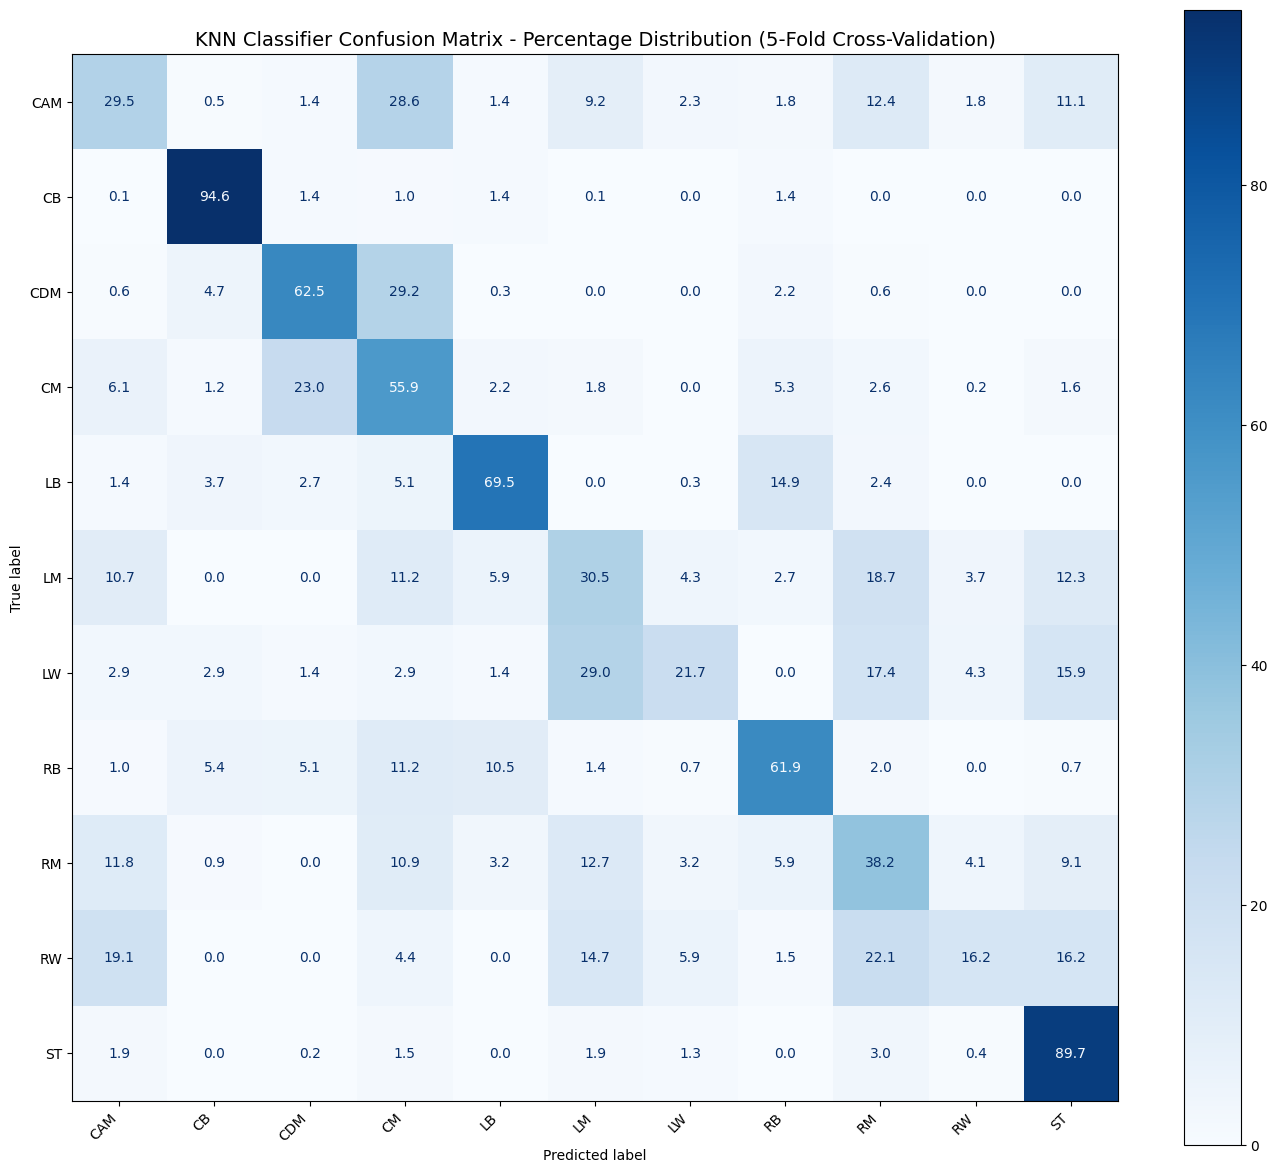

In [ ]:
# Prepare data
df_knn = df_info_reset.copy()
valid_mask = df_knn["pos"].notna() & (df_knn["pos"] != "")
df_knn = df_knn.loc[valid_mask].copy()
X_knn = X_scaled[valid_mask.values]

# Train KNN with cross-validation
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
y_pred = cross_val_predict(knn, X_knn, df_knn["pos"], cv=5)

# Plot confusion matrix with percentages
cm = confusion_matrix(df_knn["pos"], y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=sorted(df_knn["pos"].unique()))
disp.plot(ax=ax, cmap='Blues', values_format='.1f')
ax.set_title("KNN Classifier Confusion Matrix - Percentage Distribution (5-Fold Cross-Validation)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### KMeans clustering: Cluster players and look for minorities into clusters - MURA

#### KMeans algorithm

In [ ]:
noisy_columns = [
    'Playing Time_MP',      
    'Playing Time_Starts',  
    'Playing Time_Min',      
    'Playing Time_90s', 
    'Playing Time_MP',
    'Playing Time_Starts',
    '90s',                  
    'Performance_PK',       
    'Performance_PKatt',    
    'Standard_PK',            
    'Standard_PKatt'        
]

# Drop the noisy columns from the dataframe
# errors='ignore' ensures the code won't crash if a column was already removed
# Build a DataFrame from the scaled array then drop noisy columns
df_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)
df_clean = df_scaled.drop(columns=noisy_columns, errors='ignore')

# UPDATE: Sync features list with the cleaned DataFrame columns
features = df_clean.columns.tolist()

In [ ]:
# 2. Normalizzazione L2 (Il trucco per lo Stile di Gioco vs Volume)
X_normalized = normalize(df_clean, norm='l2')

k=20

# 3. K-Means "Blindato"
kmeans = KMeans(
    n_clusters=20,      # O 26, decidi tu
    n_init=50,          # Alta stabilità
    random_state=42     # Riproducibilità
)

cluster_labels = kmeans.fit_predict(X_normalized)

# Add cluster labels to the dataframe delle info (presumo contenga i nomi e i team)
df_clusters = df_info_reset.copy()
df_clusters['cluster'] = cluster_labels

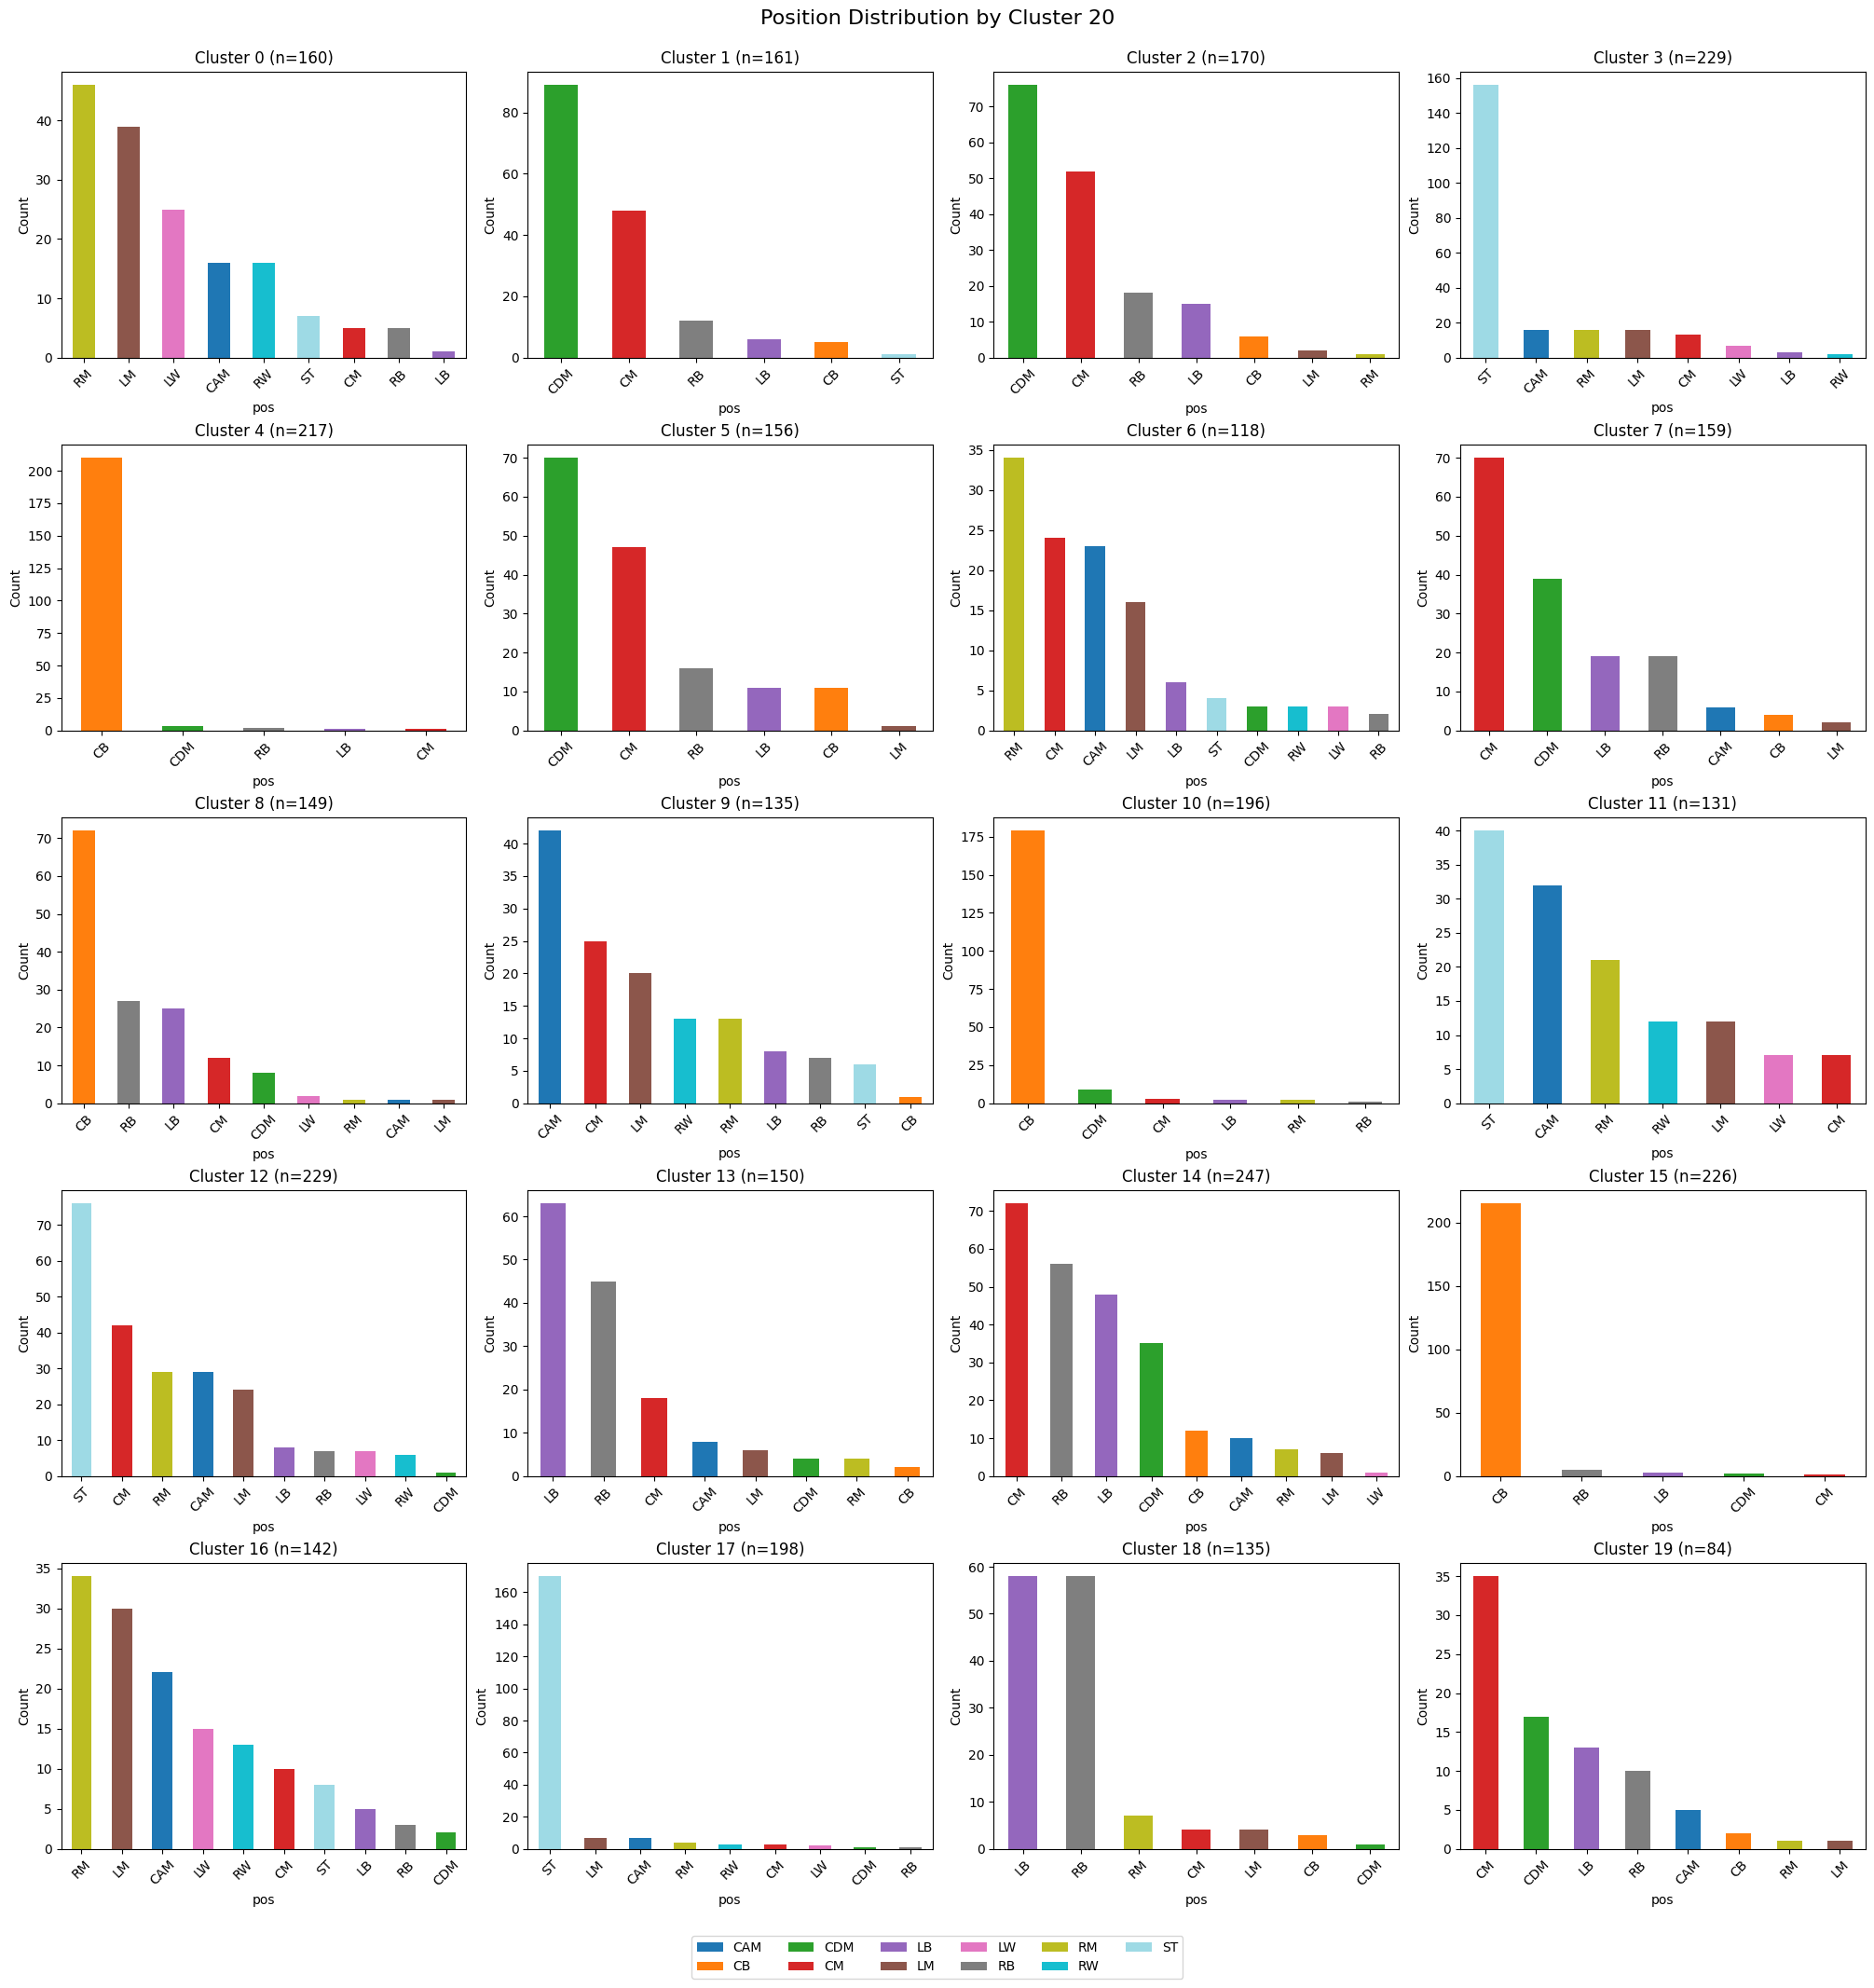

In [ ]:
# ===========================================================================
#   Visualize the distribution of positions within each cluster for KMeans A
# ===========================================================================
cluster_col = "cluster"
pos_col = "pos"

# Create a color mapping for positions
unique_positions = sorted(df_clusters[pos_col].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
color_map = {pos: colors[i] for i, pos in enumerate(unique_positions)}

n_clusters = df_clusters[cluster_col].nunique()
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), constrained_layout=True)
axes = np.array(axes).ravel()

for cluster_id in sorted(df_clusters[cluster_col].unique()):
    ax = axes[cluster_id]
    cluster_data = df_clusters[df_clusters[cluster_col] == cluster_id]
    pos_counts = cluster_data[pos_col].value_counts()

    # Map colors to each position
    bar_colors = [color_map[pos] for pos in pos_counts.index]
    pos_counts.plot(kind="bar", ax=ax, color=bar_colors)
    ax.set_title(f"Cluster {cluster_id} (n={len(cluster_data)})")
    ax.set_xlabel("pos")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

# Create legend with position colors
legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=color_map[pos], label=pos) for pos in unique_positions]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=len(unique_positions)//2 + 1, fontsize=10)

plt.suptitle(f"Position Distribution by Cluster {k}", y=1.02, fontsize=16)
plt.show()

In [ ]:
df_clusters['Dominant_Role_in_Cluster'] = df_clusters.groupby('cluster')['pos'].transform(
    lambda x: x.value_counts().idxmax()
)

df_clusters.to_csv("resources/df_clusters.csv", index=False)

#### Cluster Analysis

##### Inter-Cluster analysis

In [ ]:
glossary = pd.read_excel("resources\glossary.xlsx")

# Create glossary lookup dictionary
glossary_dict = dict(zip(glossary['KPI'], glossary['Explanation']))

cluster_profile = []

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # 1. Ruolo Dominante
    pos_counts = cluster_data['pos'].value_counts()
    most_freq_pos_str = f"{pos_counts.index[0]} ({pos_counts.iloc[0]}, {(pos_counts.iloc[0]/len(cluster_data)*100):.1f}%)"
    
    # 2. Altri Ruoli
    other_pos_list = [f"{pos} ({count}, {(count/len(cluster_data)*100):.1f}%)" for pos, count in pos_counts.iloc[1:].items()]
    other_pos = ', '.join(other_pos_list)
    
    # 3. Estrazione Feature dal K-Means
    cluster_center = kmeans.cluster_centers_[cluster_id]
    
    # Ordina tutti gli indici dal valore più alto al più basso
    sorted_idx = np.argsort(cluster_center)[::-1]
    
    # Filtra separatamente chi è > 0 (Positivi) e chi è < 0 (Negativi, ordinati dal più basso)
    pos_indices = [i for i in sorted_idx if cluster_center[i] > 0]
    neg_indices = [i for i in sorted_idx[::-1] if cluster_center[i] < 0] 
    
    # Funzione di supporto per estrarre le top K feature (aggiunge "-" se mancano)
    def get_feature_str(indices, k=3, is_positive=True):
        res = []
        for i in indices[:k]:
            val = cluster_center[i]
            sign = "+" if is_positive else ""
            # Inseriamo il nome della feature e il suo valore
            res.append(f"{features[i]} ({sign}{val:.2f})")
            
        # Riempi i vuoti se ci sono meno di 3 feature
        while len(res) < k:
            res.append("-")
        return res

    # Estrai le 3 migliori positive e le 3 peggiori negative
    pos_features = get_feature_str(pos_indices, k=3, is_positive=True)
    neg_features = get_feature_str(neg_indices, k=3, is_positive=False)
    
    # Aggiungiamo tutto al dizionario (che diventerà una riga del DataFrame)
    cluster_profile.append({
        'cluster': cluster_id,
        'player_count': len(cluster_data),
        'dominant_role': most_freq_pos_str,
        'other_positions': other_pos if other_pos else '-',
        'top_pos_1': pos_features[0],
        'top_pos_2': pos_features[1],
        'top_pos_3': pos_features[2],
        'top_neg_1': neg_features[0],
        'top_neg_2': neg_features[1],
        'top_neg_3': neg_features[2]
    })

# Crea il DataFrame finale
df_cluster_profile = pd.DataFrame(cluster_profile)

In [ ]:
scouting_reports = {
    0: "Elite Agility Wingers - Short and light wingers specialized in dribbling and carrying the ball into the opponent's penalty area. They offer zero defensive presence against shots.",
    1: "Shot-Heavy Midfield Anchors - Defensive midfielders who guard the middle third but have zero finishing efficiency. They are known for attempting shots from excessive distances.",
    2: "High-Volume Defensive Grinders - Central midfielders focused exclusively on tackling and contesting the ball. They provide zero offensive production, both actual and expected.",
    3: "Ghost-Poachers - Pure forwards with elite finishing efficiency per 90 minutes, but completely isolated from the build-up. They participate little in active play and have mediocre short passing percentages.",
    4: "Low-Block Wall - Old-school center-backs. They dominate in clearances and blocked shots. They never participate in ball progression and almost never receive the ball in forward positions.",
    5: "Central Metronomes - Playmakers who manage possession in the middle third and distribute the ball toward the final third. They are the heart of the build-up but never personally threaten the goal.",
    6: "High-Risk/Low-Reward Dribblers - Wingers who attempt many dribbles but are often stopped or lose possession. They drastically underperform compared to their expected goals and do not provide depth.",
    7: "Technical Verticalizers - Physically light central midfielders who are fundamental for vertical progression. They break lines with passing but do not have a dangerous shot.",
    8: "Clinical Aerial Threats - Defenders or fullbacks who take very few shots but are lethal when they do, likely on set pieces. They avoid advanced possession.",
    9: "Pure Playmakers - Attacking midfielders focused entirely on chance creation. Low center of gravity players who offer no defensive coverage in their own penalty area.",
    10: "Technical Giants - Tall center-backs with above-average technical cleanliness. They excel in the accuracy of medium passes and have a high success rate in defensive dribbling.",
    11: "Specialized Finishers - Forwards whose only statistical contribution is scoring. They show zero participation in the defensive phase, zero clearances, and zero tackles won.",
    12: "Inefficient Volume Shooters - Players who attempt many shots and shots on target but have very low overall involvement in the game and are often intercepted while on the ball.",
    13: "Traditional Fullbacks - Fullbacks focused on crossing into the area and direct tackling of the ball carrier. They have practically no goal-scoring ambition.",
    14: "Long-Range Shield - Holding midfielders who protect the defense and complete short passes, but in attack limit themselves to speculative shots from outside the area with poor accuracy.",
    15: "First-Phase Specialists - Center-backs who handle the first touches of the build-up in their own third. They never carry the ball forward and do not receive progressive passes.",
    16: "Final-Third Specialists - Wingers who live in the last 30 meters. They provide elite assists and expected assists but completely ignore the defensive and transition phases.",
    17: "Box-Target Strikers - Forwards who constantly position themselves to receive high-quality chances, but are technically limited in passing accuracy.",
    18: "Lockdown Wide Defenders - Stay-back fullbacks. They excel in contests, defensive tackles, and crossing, but have very poor accuracy in long passes.",
    19: "Clinical Midfield Pivots - Midfielders who manage the ball with extreme cleanliness. When they shoot they are very accurate, although they shoot rarely."
}

df_target = df_cluster_profile
nome_colonna_id = 'cluster'

df_target['scouting_report'] = df_target[nome_colonna_id].map(scouting_reports)

display(df_target[[nome_colonna_id, 'dominant_role', 'scouting_report']].head())

df_target.to_csv(r"resources\df_cluster_profile.csv", index=False)

,cluster,dominant_role,scouting_report
0,0,"RM (46, 28.7%)",Elite Agility Wingers - Short and light winger...
1,1,"CDM (89, 55.3%)",Shot-Heavy Midfield Anchors - Defensive midfie...
2,2,"CDM (76, 44.7%)",High-Volume Defensive Grinders - Central midfi...
3,3,"ST (156, 68.1%)",Ghost-Poachers - Pure forwards with elite fini...
4,4,"CB (210, 96.8%)",Low-Block Wall - Old-school center-backs. They...


In [ ]:
pivot_pos = pd.crosstab(df_clusters['cluster'], df_clusters['pos'])
pivot_norm = pivot_pos.div(pivot_pos.sum(axis=1), axis=0)
pos_corr = pivot_norm.corr()

# Sort the correlation matrix by the specified position order
position_order = ['CB', 'RB', 'LB', 'CDM', 'CM', 'RM', 'LM', 'CAM', 'RW', 'LW', 'ST']
# Filter to keep only positions that exist in the data
position_order = [pos for pos in position_order if pos in pos_corr.columns]
pos_corr = pos_corr.loc[position_order, position_order]

fig = px.imshow(
    pos_corr,
    labels=dict(x="Position", y="Position", color="Correlation"),
    x=pos_corr.columns,
    y=pos_corr.columns,
    color_continuous_scale='RdBu_r',
    zmin=-0.5,
    zmax=1,
    text_auto='.2f',
    aspect='auto',
    title="Tactical Similarity Between Positions Based on Cluster Distribution Correlation"
)

fig.update_layout(
    title_x=0.5,
    width=900,
    height=800,
    xaxis_tickangle=-45
)

fig.show()

##### Intra-Cluster Analysis [Functions]

In [ ]:
def analyze_cluster(cluster_id):

    dominant_pos = df_cluster_profile.loc[cluster_id, "dominant_role"].split(" ")[0]
    
    print("==============================")
    print(f"Cluster {cluster_id} Profile:")
    print("==============================")
    print("Top 5 features: ")
    for col in ['top_pos_1', 'top_pos_2', 'top_pos_3', 'top_neg_1', 'top_neg_2', 'top_neg_3']:
        feature = df_cluster_profile.loc[cluster_id, col]
        print(f"{col}: {feature}")
        # Extract feature name (before the parenthesis)
        if feature != "-":
            feature_name = feature.split(" (")[0]
            if feature_name in glossary_dict:
                print(f"  → {glossary_dict[feature_name][:100]}...")
    print("Most frequent position: ", df_cluster_profile.loc[cluster_id, "dominant_role"])
    print("Other positions: ", df_cluster_profile.loc[cluster_id, "other_positions"])
    print("==============================")
    print("Average profile:")
    print(df_cluster_profile.loc[cluster_id, "scouting_report"])
    print("==============================")
    print(f"Anomalies in Cluster {cluster_id}:")
    display(df_clusters[(df_clusters['cluster'] == cluster_id) & (df_clusters['pos'] != dominant_pos)][['player', 'pos', 'team', 'season']])
    print("==============================")
    
analyze_cluster(18)

Cluster 18 Profile:
Top 5 features: 
top_pos_1: CrsPA (+0.21)
  → Completed crosses into the opponent's penalty area (excluding set pieces)....
top_pos_2: Challenges_Tkl (+0.10)
  → Number of times a player successfully tackled an opponent who was dribbling....
top_pos_3: Tackles_Def 3rd (+0.10)
  → Number of tackles performed in the defensive third of the pitch....
top_neg_1: Long_Cmp% (-0.13)
  → Percentage of long passes successfully completed....
top_neg_2: Standard_Sh/90 (-0.11)
  → Average number of shots taken per 90 minutes....
top_neg_3: Standard_SoT/90 (-0.11)
  → Average number of shots on target per 90 minutes....
Most frequent position:  LB (58, 43.0%)
Other positions:  RB (58, 43.0%), RM (7, 5.2%), CM (4, 3.0%), LM (4, 3.0%), CB (3, 2.2%), CDM (1, 0.7%)
Average profile:
Lockdown Wide Defenders - Stay-back fullbacks. They excel in contests, defensive tackles, and crossing, but have very poor accuracy in long passes.
Anomalies in Cluster 18:


,player,pos,team,season
21,Matty Cash,RB,Aston Villa,2024 - 2025
49,Vitaly Janelt,CM,Brentford,2024 - 2025
96,Ashley Young,RB,Everton,2024 - 2025
230,Djed Spence,RB,Tottenham,2024 - 2025
290,Nahuel Molina,RB,Atlético Madrid,2024 - 2025
...,...,...,...,...
3271,Manuel Lazzari,RB,Lazio,2022 - 2023
3312,Samuele Birindelli,RB,Monza,2022 - 2023
3335,Zeki Çelik,RB,Roma,2022 - 2023
3366,Kelvin Amian,RB,Spezia,2022 - 2023


In [ ]:
def plot_cluster_positions(cluster_id, df_clusters=df_clusters):
    """
    Create a bar plot showing the distribution of positions in a specific cluster
    """
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    pos_counts = cluster_data['pos'].value_counts().reset_index()
    pos_counts.columns = ['Position', 'Count']
    
    unique_positions = sorted(df_clusters['pos'].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
    color_map = {
        pos: f'#{int(colors[i][0]*255):02x}{int(colors[i][1]*255):02x}{int(colors[i][2]*255):02x}'
        for i, pos in enumerate(unique_positions)
    }
    
    fig = px.bar(
        pos_counts,
        x='Position',
        y='Count',
        title=f'Position Distribution in Cluster {cluster_id}',
        labels={'Count': 'Number of Players', 'Position': 'Position'},
        color='Position',
        color_discrete_map=color_map,
        text='Count'
    )
    fig.update_traces(textposition='auto')
    fig.update_layout(title_x=0.5)
    fig.show()

def plot_cluster_league(cluster_id, df_clusters=df_clusters):
    """
    Create a bar plot showing the normalized distribution of leagues in a specific cluster
    (normalized by the total number of players in each league)
    """
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # Count players by league in this cluster
    league_counts_cluster = cluster_data['league'].value_counts().reset_index()
    league_counts_cluster.columns = ['League', 'Count_in_Cluster']
    
    # Count total players by league in the entire dataset
    league_counts_total = df_clusters['league'].value_counts().reset_index()
    league_counts_total.columns = ['League', 'Total_Count']
    
    # Merge and calculate normalized percentage
    league_data = league_counts_cluster.merge(league_counts_total, on='League')
    league_data['Percentage'] = (league_data['Count_in_Cluster'] / league_data['Total_Count'] * 100).round(1)
    
    # Sort by percentage descending
    league_data = league_data.sort_values('Percentage', ascending=False)
    
    # Define league colors with hex codes
    league_colors = {
        'ESP-La Liga': "#FF4B44",
        'ENG-Premier League': '#04F5FF',
        'GER-Bundesliga': "#777777",
        'FRA-Ligue 1': '#CDFB0A',
        'ITA-Serie A': '#0578FF'
    }
    
    fig = px.bar(
        league_data,
        x='League',
        y='Percentage',
        title=f'League Distribution in Cluster {cluster_id} (Normalized by League Size)',
        labels={'Percentage': '% of League Players in Cluster', 'League': 'League'},
        text='Percentage',
        color='League',
        color_discrete_map=league_colors,
        hover_data={'Count_in_Cluster': True, 'Total_Count': True, 'Percentage': ':.1f'}
    )
    
    fig.update_traces(textposition='auto', marker_line_width=0.2, marker_line_color='black')
    fig.update_layout(title_x=0.5, xaxis_tickangle=-45, showlegend=False)
    fig.show()
    
plot_cluster_league(0)

### Autoencoder Reconstruction Error - BOSCA

In [90]:
print("--- Building Autoencoder (sklearn MLPRegressor) ---")

from sklearn.neural_network import MLPRegressor
import numpy as np

input_dim = X_scaled.shape[1]

# ==========================================
# 1. AUTOENCODER (MLP as encoder-decoder)
# ==========================================

autoencoder = MLPRegressor(
    hidden_layer_sizes=(64, 32, 10, 32, 64),  # bottleneck = 10
    activation='tanh',
    solver='adam',
    max_iter=300,
    random_state=42
)

# TRAINING (input = output → autoencoder behavior)
print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled)
print("Training completed!")

# ==========================================
# 2. RECONSTRUCTION
# ==========================================

print("\nCalculating reconstruction error...")

X_reconstructed = autoencoder.predict(X_scaled)

# Mean Squared Error per player
reconstruction_errors = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

# ==========================================
# 3. OUTPUT DATAFRAME
# ==========================================

df_reconstruction_error = df_info_reset.copy()
df_reconstruction_error['reconstruction_error'] = reconstruction_errors

print("\nPlayers with highest reconstruction error (potential anomalies):")

display(
    df_reconstruction_error
    .sort_values(by='reconstruction_error', ascending=False)
    .head(10)
)

--- Building Autoencoder (sklearn MLPRegressor) ---

Training in progress...
Training completed!

Calculating reconstruction error...

Players with highest reconstruction error (potential anomalies):


,league,season,team,player,nation,age,born,preferred_foot,pos,reconstruction_error
1322,ENG-Premier League,2023 - 2024,Fulham,Tim Ream,USA,35,1987,Left,CB,1.958673
1582,ESP-La Liga,2023 - 2024,Rayo Vallecano,Florian Lejeune,FRA,32,1991,Right,CB,0.754782
456,ESP-La Liga,2024 - 2025,Valladolid,Mario Martín,ESP,20,2004,Right,CM,0.571328
3358,ITA-Serie A,2022 - 2023,Sassuolo,Ruan,BRA,23,1999,Right,RM,0.561565
2728,ESP-La Liga,2022 - 2023,Sevilla,Marcos Acuña,ARG,30,1991,Left,LB,0.514338
2696,ESP-La Liga,2022 - 2023,Rayo Vallecano,Florian Lejeune,FRA,31,1991,Right,CB,0.499436
2697,ESP-La Liga,2022 - 2023,Rayo Vallecano,Fran Garcia,ESP,22,1999,Left,LB,0.495069
291,ESP-La Liga,2024 - 2025,Atlético Madrid,Pablo Barrios,ESP,21,2003,Right,CM,0.487749
302,ESP-La Liga,2024 - 2025,Barcelona,Lamine Yamal,ESP,17,2007,Left,RM,0.472382
2430,ENG-Premier League,2022 - 2023,Everton,James Tarkowski,ENG,29,1992,Right,CB,0.467802


In [91]:
print("--- Building Autoencoder per Player Position (sklearn) ---")

from sklearn.neural_network import MLPRegressor
import numpy as np
import pandas as pd

unique_positions = df_info_reset['pos'].unique()

all_reconstruction_errors_by_pos = []

for pos_name in unique_positions:
    print(f"\nProcessing position: {pos_name}...")

    # Filter data for current position
    position_mask = df_info_reset['pos'] == pos_name
    X_scaled_pos = X_scaled[position_mask]
    df_info_pos = df_info_reset[position_mask].copy()

    # Need enough data
    if X_scaled_pos.shape[0] < 2:
        print(f"  Skipping {pos_name}: not enough players.")
        continue

    # ==========================================
    # AUTOENCODER (MLPRegressor)
    # ==========================================

    autoencoder_pos = MLPRegressor(
        hidden_layer_sizes=(64, 32, 10, 32, 64),
        activation='tanh',
        solver='adam',
        max_iter=300,
        random_state=42
    )

    # TRAINING
    print(f"  Training autoencoder for {pos_name}...")
    autoencoder_pos.fit(X_scaled_pos, X_scaled_pos)

    # ==========================================
    # RECONSTRUCTION ERROR
    # ==========================================

    X_reconstructed_pos = autoencoder_pos.predict(X_scaled_pos)

    reconstruction_errors_pos = np.mean(
        (X_scaled_pos - X_reconstructed_pos) ** 2,
        axis=1
    )

    # Store results
    df_reconstruction_error_pos = df_info_pos.copy()
    df_reconstruction_error_pos['reconstruction_error'] = reconstruction_errors_pos

    all_reconstruction_errors_by_pos.append(df_reconstruction_error_pos)

    print(f"  Top anomalies for {pos_name}:")

    display(
        df_reconstruction_error_pos
        .sort_values(by='reconstruction_error', ascending=False)
        .head(10)
    )

# ==========================================
# FINAL TABLE
# ==========================================

if all_reconstruction_errors_by_pos:
    df_all_position_anomalies = pd.concat(
        all_reconstruction_errors_by_pos,
        ignore_index=True
    )

    print("\n--- All Position-Specific Anomalies (Top 10 overall) ---")

    display(
        df_all_position_anomalies
        .sort_values(by='reconstruction_error', ascending=False)
        .head(10)
    )

else:
    print("\nNo models trained due to insufficient data.")

--- Building Autoencoder per Player Position (sklearn) ---

Processing position: RW...
  Training autoencoder for RW...
  Top anomalies for RW:


,league,season,team,player,nation,age,born,preferred_foot,pos,reconstruction_error
2907,FRA-Ligue 1,2022 - 2023,Paris S-G,Lionel Messi,ARG,35,1987,Left,RW,0.654415
1199,ENG-Premier League,2023 - 2024,Arsenal,Bukayo Saka,ENG,21,2001,Left,RW,0.336266
196,ENG-Premier League,2024 - 2025,Nott'ham Forest,Anthony Elanga,SWE,22,2002,Right,RW,0.332268
621,FRA-Ligue 1,2024 - 2025,Paris S-G,Désiré Doué,FRA,19,2005,Right,RW,0.284905
1773,FRA-Ligue 1,2023 - 2024,Nice,Evann Guessand,CIV,22,2001,Right,RW,0.275093
249,ENG-Premier League,2024 - 2025,West Ham,Mohammed Kudus,GHA,23,2000,Left,RW,0.270155
1442,ENG-Premier League,2023 - 2024,West Ham,Mohammed Kudus,GHA,22,2000,Left,RW,0.257494
1125,ITA-Serie A,2024 - 2025,Napoli,Matteo Politano,ITA,30,1993,Left,RW,0.235220
2341,ENG-Premier League,2022 - 2023,Arsenal,Bukayo Saka,ENG,20,2001,Left,RW,0.233424
418,ESP-La Liga,2024 - 2025,Real Madrid,Rodrygo,BRA,23,2001,Right,RW,0.215959



Processing position: CDM...
  Training autoencoder for CDM...
  Top anomalies for CDM:


,league,season,team,player,nation,age,born,preferred_foot,pos,reconstruction_error
2195,ITA-Serie A,2023 - 2024,Inter,Hakan Çalhanoğlu,TUR,29,1994,Right,CDM,0.571699
501,FRA-Ligue 1,2024 - 2025,Le Havre,Abdoulaye Touré,GUI,30,1994,Right,CDM,0.554833
1190,ITA-Serie A,2024 - 2025,Venezia,Hans Nicolussi Caviglia,ITA,24,2000,Right,CDM,0.540907
1369,ENG-Premier League,2023 - 2024,Manchester City,Rodri,ESP,27,1996,Right,CDM,0.442154
1990,GER-Bundesliga,2023 - 2024,Leverkusen,Granit Xhaka,SUI,30,1992,Left,CDM,0.383039
224,ENG-Premier League,2024 - 2025,Tottenham,Archie Gray,ENG,18,2006,Right,CDM,0.379358
2395,ENG-Premier League,2022 - 2023,Brighton,Pascal Groß,GER,31,1991,Right,CDM,0.375638
1261,ENG-Premier League,2023 - 2024,Brighton,Pascal Groß,GER,32,1991,Right,CDM,0.352780
1648,FRA-Ligue 1,2023 - 2024,Brest,Pierre Lees-Melou,FRA,30,1993,Right,CDM,0.345076
363,ESP-La Liga,2024 - 2025,Las Palmas,Dario Essugo,POR,19,2005,Right,CDM,0.325283



Processing position: LW...
  Training autoencoder for LW...
  Top anomalies for LW:


...

,league,season,team,player,nation,age,born,preferred_foot,pos,reconstruction_error
153,ENG-Premier League,2024 - 2025,Liverpool,Mohamed Salah,EGY,32,1992,Left,RM,0.849037
3358,ITA-Serie A,2022 - 2023,Sassuolo,Ruan,BRA,23,1999,Right,RM,0.567914
302,ESP-La Liga,2024 - 2025,Barcelona,Lamine Yamal,ESP,17,2007,Left,RM,0.532032
566,FRA-Ligue 1,2024 - 2025,Marseille,Mason Greenwood,ENG,22,2001,Left,RM,0.368034
2779,FRA-Ligue 1,2022 - 2023,Brest,Franck Honorat,FRA,25,1996,Right,RM,0.366503
1337,ENG-Premier League,2023 - 2024,Liverpool,Mohamed Salah,EGY,31,1992,Left,RM,0.356347
1521,ESP-La Liga,2023 - 2024,Cádiz,Iván Alejo,ESP,28,1995,Right,RM,0.333303
3188,ITA-Serie A,2022 - 2023,Bologna,Riccardo Orsolini,ITA,25,1997,Left,RM,0.329451
2416,ENG-Premier League,2022 - 2023,Crystal Palace,Jordan Ayew,GHA,30,1991,Right,RM,0.320347
1295,ENG-Premier League,2023 - 2024,Crystal Palace,Jordan Ayew,GHA,31,1991,Right,RM,0.306700



Processing position: CAM...
  Training autoencoder for CAM...
  Top anomalies for CAM:


,league,season,team,player,nation,age,born,preferred_foot,pos,reconstruction_error
2879,FRA-Ligue 1,2022 - 2023,Montpellier,Téji Savanier,FRA,30,1991,Right,CAM,0.602569
2500,ENG-Premier League,2022 - 2023,Manchester Utd,Bruno Fernandes,POR,27,1994,Right,CAM,0.536322
85,ENG-Premier League,2024 - 2025,Crystal Palace,Eberechi Eze,ENG,26,1998,Right,CAM,0.493730
1276,ENG-Premier League,2023 - 2024,Chelsea,Cole Palmer,ENG,21,2002,Left,CAM,0.454075
2159,ITA-Serie A,2023 - 2024,Frosinone,Matìas Soulé,ARG,20,2003,Left,CAM,0.450551
1372,ENG-Premier League,2023 - 2024,Manchester Utd,Alejandro Garnacho,ARG,19,2004,Right,CAM,0.398348
172,ENG-Premier League,2024 - 2025,Manchester Utd,Bruno Fernandes,POR,29,1994,Right,CAM,0.393466
218,ENG-Premier League,2024 - 2025,Southampton,Mateus Fernandes,POR,20,2004,Right,CAM,0.392880
3000,GER-Bundesliga,2022 - 2023,Dortmund,Jude Bellingham,ENG,19,2003,Right,CAM,0.376909
818,GER-Bundesliga,2024 - 2025,Leverkusen,Florian Wirtz,GER,21,2003,Right,CAM,0.352506



--- All Position-Specific Anomalies (Top 10 overall) ---


,league,season,team,player,nation,age,born,preferred_foot,pos,reconstruction_error
836,ESP-La Liga,2023 - 2024,Rayo Vallecano,Florian Lejeune,FRA,32,1991,Right,CB,1.427008
781,ENG-Premier League,2023 - 2024,Fulham,Tim Ream,USA,35,1987,Left,CB,0.980090
708,ITA-Serie A,2024 - 2025,Como,Nicolás Paz,ARG,19,2004,Right,CB,0.942299
2968,ENG-Premier League,2024 - 2025,Liverpool,Mohamed Salah,EGY,32,1992,Left,RM,0.849037
61,FRA-Ligue 1,2022 - 2023,Paris S-G,Lionel Messi,ARG,35,1987,Left,RW,0.654415
2042,ESP-La Liga,2024 - 2025,Valladolid,Mario Martín,ESP,20,2004,Right,CM,0.608504
3350,FRA-Ligue 1,2022 - 2023,Montpellier,Téji Savanier,FRA,30,1991,Right,CAM,0.602569
304,ITA-Serie A,2023 - 2024,Inter,Hakan Çalhanoğlu,TUR,29,1994,Right,CDM,0.571699
3172,ITA-Serie A,2022 - 2023,Sassuolo,Ruan,BRA,23,1999,Right,RM,0.567914
131,FRA-Ligue 1,2024 - 2025,Le Havre,Abdoulaye Touré,GUI,30,1994,Right,CDM,0.554833


Visualizing Position-Specific Autoencoder Anomalies
The following plots illustrate the players with the highest reconstruction errors for each position. These are the players whose statistical profiles are most 'unusual' when compared to their peers playing the same role, as detected by the position-specific autoencoders.

In [92]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assuming df_all_position_anomalies is available from the previous execution
# If not, ensure the previous cell (oZ1QZVRE4Jej) has been run.

if 'df_all_position_anomalies' not in locals():
    print("Error: 'df_all_position_anomalies' DataFrame not found. Please ensure the previous cell has been executed.")
else:
    for pos_name in df_all_position_anomalies['pos'].unique():
        df_pos_anomalies = df_all_position_anomalies[df_all_position_anomalies['pos'] == pos_name]
        df_pos_anomalies_top10 = df_pos_anomalies.sort_values(by='reconstruction_error', ascending=False).head(10)

        if not df_pos_anomalies_top10.empty:
            fig = px.bar(
                df_pos_anomalies_top10,
                x='player',
                y='reconstruction_error',
                title=f'Top 10 Anomalies for {pos_name} (Highest Reconstruction Error)',
                labels={'player': 'Player', 'reconstruction_error': 'Reconstruction Error'},
                hover_data=['team', 'league', 'season', 'age', 'nation'],
                color_discrete_sequence=px.colors.qualitative.Plotly # Use a qualitative color scale
            )

            fig.update_layout(
                xaxis_title='Player Name',
                yaxis_title='Reconstruction Error',
                title_x=0.5,
                height=500,
                showlegend=False
            )
            fig.update_traces(marker_color='lightblue', marker_line_color='black', marker_line_width=1.5)

            fig.show()
        else:
            print(f"No anomalies to display for position: {pos_name}")


Top 5 Anomalous Players by Role

In [93]:
if 'df_all_position_anomalies' not in locals():
    print("Error: 'df_all_position_anomalies' DataFrame not found. Please ensure the previous cell has been executed.")
else:
    for pos_name in df_all_position_anomalies['pos'].unique():
        df_pos_anomalies = df_all_position_anomalies[df_all_position_anomalies['pos'] == pos_name]
        df_pos_anomalies_top5 = df_pos_anomalies.sort_values(by='reconstruction_error', ascending=False).head(5)

        if not df_pos_anomalies_top5.empty:
            print(f"\nTop 5 Anomalies for Position: {pos_name}")
            display(df_pos_anomalies_top5[['player', 'team', 'season', 'age', 'reconstruction_error']])
        else:
            print(f"No anomalies to display for position: {pos_name}")


Top 5 Anomalies for Position: RW


,player,team,season,age,reconstruction_error
61,Lionel Messi,Paris S-G,2022 - 2023,35,0.654415
20,Bukayo Saka,Arsenal,2023 - 2024,21,0.336266
5,Anthony Elanga,Nott'ham Forest,2024 - 2025,22,0.332268
15,Désiré Doué,Paris S-G,2024 - 2025,19,0.284905
36,Evann Guessand,Nice,2023 - 2024,22,0.275093



Top 5 Anomalies for Position: CDM


,player,team,season,age,reconstruction_error
304,Hakan Çalhanoğlu,Inter,2023 - 2024,29,0.571699
131,Abdoulaye Touré,Le Havre,2024 - 2025,30,0.554833
197,Hans Nicolussi Caviglia,Venezia,2024 - 2025,24,0.540907
218,Rodri,Manchester City,2023 - 2024,27,0.442154
290,Granit Xhaka,Leverkusen,2023 - 2024,30,0.383039



Top 5 Anomalies for Position: LW


...

,player,team,season,age,reconstruction_error
2884,Jan-Niklas Beste,Heidenheim,2023 - 2024,24,0.497323
2787,Raphinha,Barcelona,2024 - 2025,27,0.365349
2921,Sergi Darder,Espanyol,2022 - 2023,28,0.333911
2911,Marcus Rashford,Manchester Utd,2022 - 2023,24,0.312545
2888,Matteo Ruggeri,Atalanta,2023 - 2024,21,0.294308



Top 5 Anomalies for Position: RM


,player,team,season,age,reconstruction_error
2968,Mohamed Salah,Liverpool,2024 - 2025,32,0.849037
3172,Ruan,Sassuolo,2022 - 2023,23,0.567914
2974,Lamine Yamal,Barcelona,2024 - 2025,17,0.532032
2996,Mason Greenwood,Marseille,2024 - 2025,22,0.368034
3137,Franck Honorat,Brest,2022 - 2023,25,0.366503



Top 5 Anomalies for Position: CAM


,player,team,season,age,reconstruction_error
3350,Téji Savanier,Montpellier,2022 - 2023,30,0.602569
3335,Bruno Fernandes,Manchester Utd,2022 - 2023,27,0.536322
3182,Eberechi Eze,Crystal Palace,2024 - 2025,26,0.493730
3257,Cole Palmer,Chelsea,2023 - 2024,21,0.454075
3314,Matìas Soulé,Frosinone,2023 - 2024,20,0.450551


## End

In [ ]:
end_time = time.time()

In [ ]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 0.10 min
